In [36]:
import sys
import os

sys.path.append(os.path.abspath("../src"))  # путь к твоему utils.py

from utils import load_and_clean_data

df = load_and_clean_data("../data/raw/spam.csv")

import matplotlib.pyplot as plt
from wordcloud import WordCloud
import matplotlib.colors as mcolors

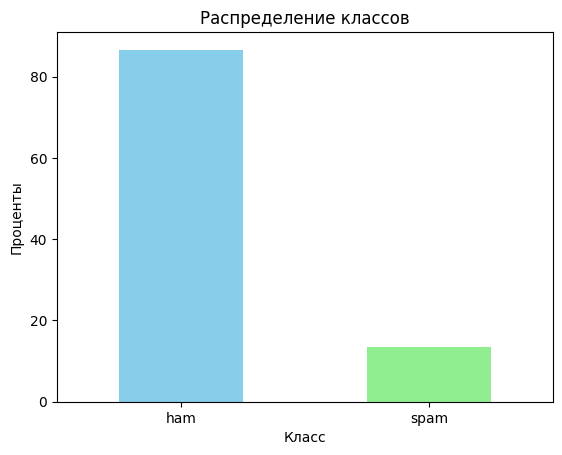

In [ ]:
# РАСПРЕДЕЛЕНИЕ КЛАССОВ

# формируем столбчатую диаграмму
(df['label'].value_counts(normalize=True) * 100).plot(kind='bar', color=['skyblue', 'lightgreen'])

# название диаграммы
plt.title("Распределение классов")

# наименование оси х
plt.xlabel("Класс")

# наименование оси y
plt.ylabel("Проценты")

# визуализация диаграммы
plt.xticks(rotation=0)
plt.show()

# Распределение классов 📚

📊 Данный график показывает, сколько в процентном соотношении имеется сообщений, которые относятся к типу "spam" и "ham".

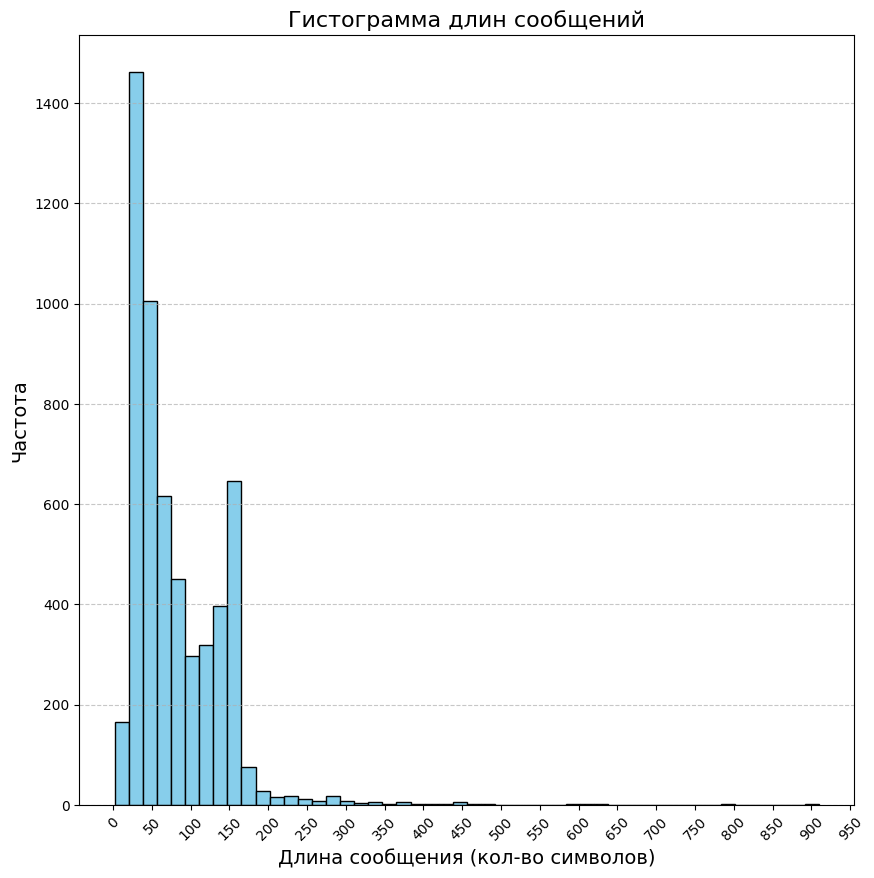

In [31]:
# ГИСТОГРАММА ДЛИНЫ СООБЩЕНИЙ

# Вычисляем длины сообщений
message_lengths = df['message'].str.len()

# Создаём гистограмму
plt.figure(figsize=(10, 10))  # Устанавливаем размер графика
plt.hist(message_lengths, bins=50, color='skyblue', edgecolor='black')  # bins — количество столбцов

# Настройка графика
plt.title('Гистограмма длин сообщений', fontsize=16)
plt.xlabel('Длина сообщения (кол-во символов)', fontsize=14)
plt.ylabel('Частота', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)  # Добавляем сетку по оси Y

# Устанавливаем деления на оси X с шагом 50
x_ticks = range(0, int(message_lengths.max()) + 50, 50)  # От 0 до max длины с шагом 50
plt.xticks(x_ticks, rotation=45)

# Отображаем график
plt.show()

# Гистограмма длины сообщений 📚

📶 Данная гистограмма демонстрирует частоту получения сообщений N-ой длинны.

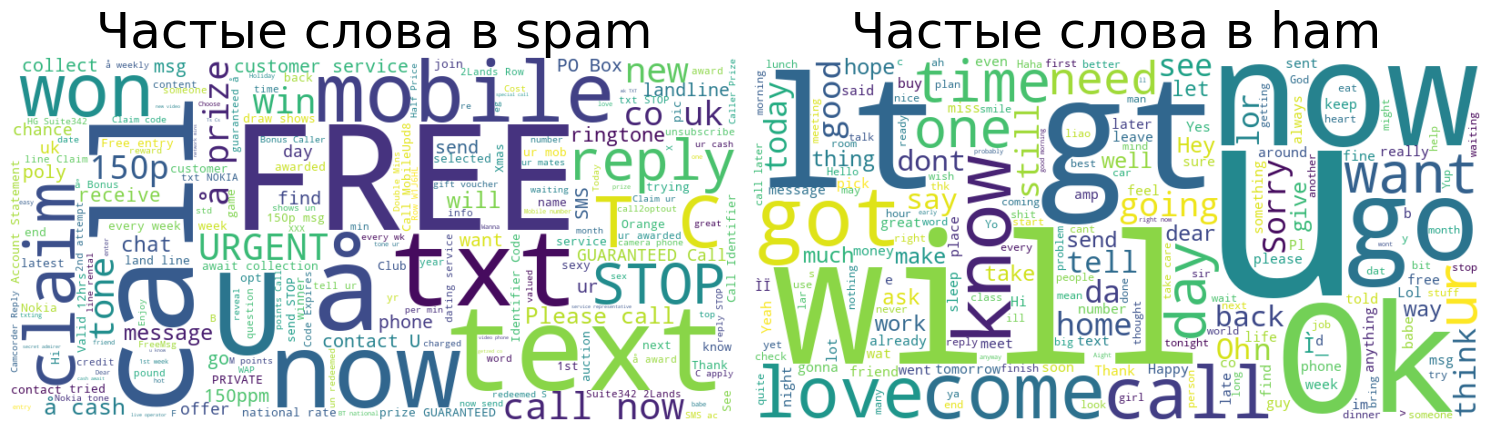

In [ ]:
# ТОП 20 СЛОВ ДЛЯ SPAM И HAM

# Текст для спама и хама
text_spam = " ".join(df[df['label'] == 'spam']['message'])
text_ham = " ".join(df[df['label'] == 'ham']['message'])

# Создание WordCloud для спама с красными оттенками
wordcloud_spam = WordCloud(
    width=800,
    height=400,
    background_color='white',
).generate(text_spam)

# Создание WordCloud для хама с зелёными оттенками
wordcloud_ham = WordCloud(
    width=800,
    height=400,
    background_color='white',
).generate(text_ham)

# Создание фигуры с двумя графиками рядом
fig, axes = plt.subplots(1, 2, figsize=(15, 8))  # 1 строка, 2 столбца

# Вывод WordCloud для спама
axes[0].imshow(wordcloud_spam, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title("Частые слова в spam", fontsize=36)

# Вывод WordCloud для хама
axes[1].imshow(wordcloud_ham, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title("Частые слова в ham", fontsize=36)

# Отображение графиков
plt.tight_layout()
plt.show()

# Топ 20 слов для spam и ham 📚

📕|📗 Два данных графика визуализируют частоту слов - чем чаще слово встречается - тем больше оно на изображении. 
При данном подходе мы можем наглядно сравнить то, какие слова, скорее всего, являются ключевыми для отправки в спам, а какие мы должны будем пропускать.